# Grasp adaptation — compliance-matched stiffness control

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.join('../'))
from plot_config import draw_radar

OUTPUT_DIR = os.path.join('outputs', 'grasp_adaptation')
OBJECTS    = ['hard_obj', 'soft_obj']
COLORS     = {'hard_obj': '#0072B2', 'soft_obj': '#D55E00'}

def load_latest(obj):
    folder = Path(OUTPUT_DIR)
    if not folder.exists():
        return None
    files = sorted(folder.glob(f'grasp_{obj}*.csv'))
    return pd.read_csv(files[-1]) if files else None

data = {obj: load_latest(obj) for obj in OBJECTS}

## Sensing phase — fingertip displacement per object

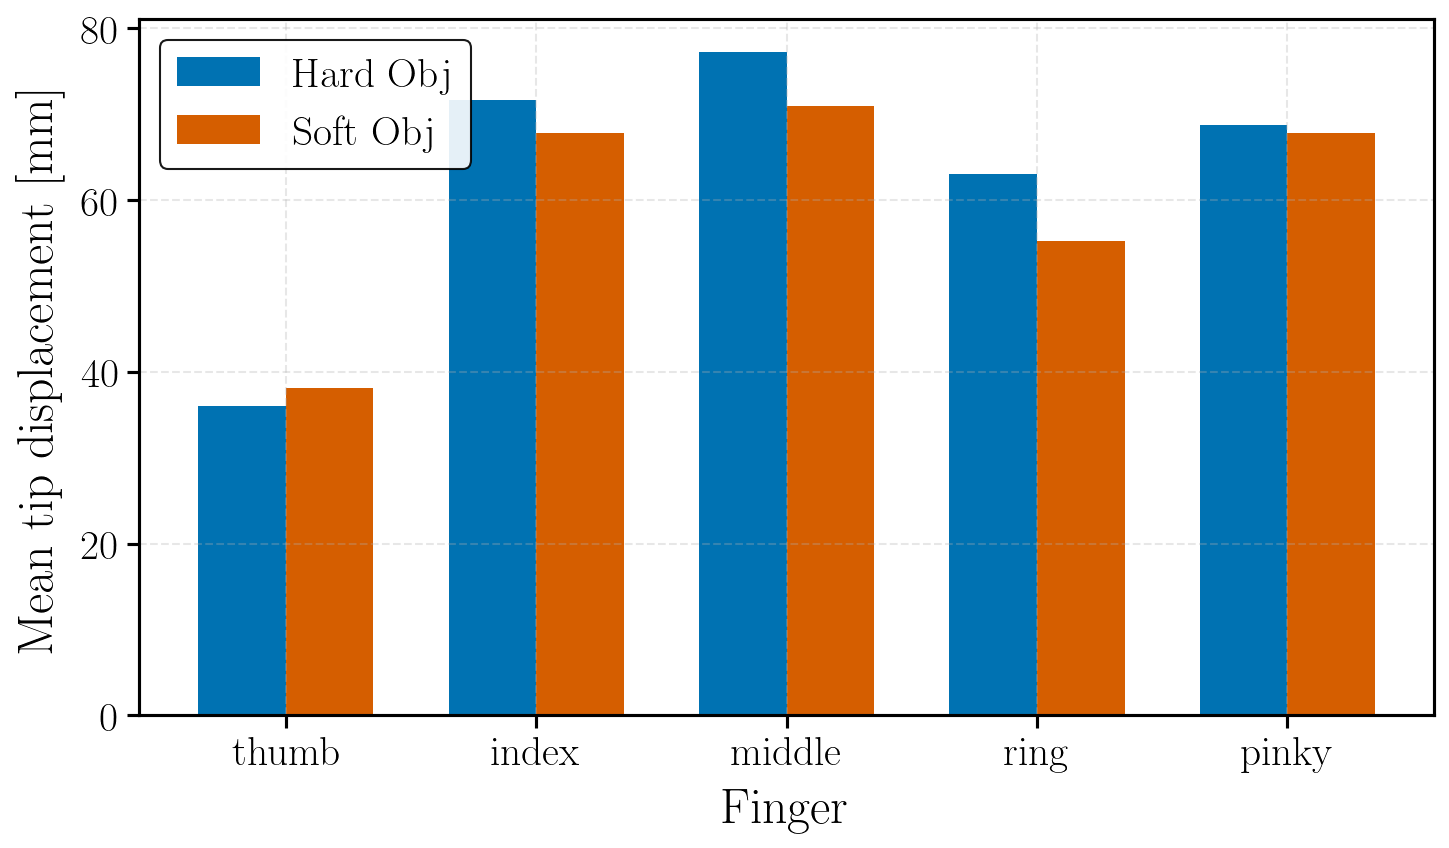

In [11]:
fig, ax = plt.subplots()

FINGERTIPS = ['thumb', 'index', 'middle', 'ring', 'pinky']
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, (obj, color) in enumerate(COLORS.items()):
    df = data[obj]
    if df is None:
        continue
    sense = df[df['phase'] == 'sense']
    means = [sense[f'disp_{f}_mag_m'].mean() * 1e3 for f in FINGERTIPS]
    ax.bar(x + i * width, means, width, label=obj.replace('_', ' ').title(),
           color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel('Mean tip displacement [mm]')
ax.legend()
fig.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'sensing_displacement.pdf'), bbox_inches='tight')
plt.show()

## Adapted stiffness — sensing displacement vs k_applied

In [12]:
fig, ax = plt.subplots()

# Overlay the adaptation curve k = K_GAIN / delta (clipped to [K_MIN, K_MAX]).
from hand_config import K_GAIN, K_MIN, K_MAX

FINGERTIPS = ['thumb', 'index', 'middle', 'ring', 'pinky']
delta_range = np.linspace(1e-4, 0.05, 300)
k_curve     = np.clip(K_GAIN / delta_range, K_MIN, K_MAX)
ax.plot(delta_range * 1e3, k_curve, color='0.5', lw=1, linestyle='--',
        label='adaptation curve')

for obj, color in COLORS.items():
    df = data[obj]
    if df is None:
        continue
    sense = df[df['phase'] == 'sense']
    delta = float(sense[[f'disp_{f}_mag_m' for f in FINGERTIPS]].mean(axis=1).mean()) * 1e3
    k_app = float(sense['k_applied_Npm'].iloc[-1])
    ax.scatter([delta], [k_app], color=color, zorder=5,
               label=obj.replace('_', ' ').title())
    ax.annotate(f'{k_app:.0f} N/m', (delta, k_app),
                textcoords='offset points', xytext=(6, 4))

ax.set_xlabel('δ_mean [mm]')
ax.set_ylabel('k_applied [N/m]')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'adaptation_curve.pdf'), bbox_inches='tight')
plt.show()

RuntimeError: latex was not able to process the following string:
b'\\u03b4_mean [mm]'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty)
(/usr/share/texlive/texmf-d

Error in callback <function _draw_all_if_interactive at 0x7e9be00b7880> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'\\u03b4_mean [mm]'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty)
(/usr/share/texlive/texmf-d

RuntimeError: latex was not able to process the following string:
b'\\u03b4_mean [mm]'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty)
(/usr/share/texlive/texmf-d

<Figure size 1500x900 with 1 Axes>